# Portfolio Analysis
Analysis of ISA and SIPP portfolio values from the HL investment dashboard.

In [11]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

con = duckdb.connect('data/hl_dashboard.duckdb', read_only=True)

## Portfolio Value Over Time

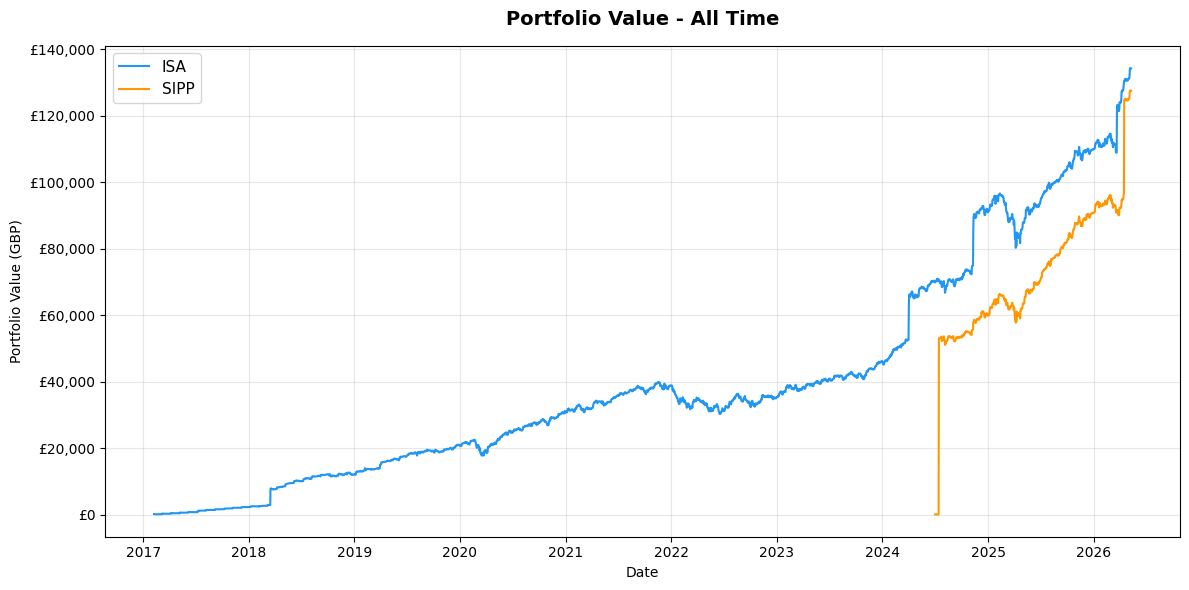

In [12]:
df = con.execute(
    'SELECT valuation_date, account_name, portfolio_value_gbp FROM mart_daily_portfolio_value ORDER BY valuation_date'
).fetchdf()

isa = df[df['account_name'] == 'ISA'].set_index('valuation_date')['portfolio_value_gbp']
sipp = df[df['account_name'] == 'SIPP'].set_index('valuation_date')['portfolio_value_gbp']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(isa.index, isa.values, label='ISA', linewidth=1.5, color='#2196F3')
ax.plot(sipp.index, sipp.values, label='SIPP', linewidth=1.5, color='#FF9800')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Portfolio Value - All Time', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (GBP)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

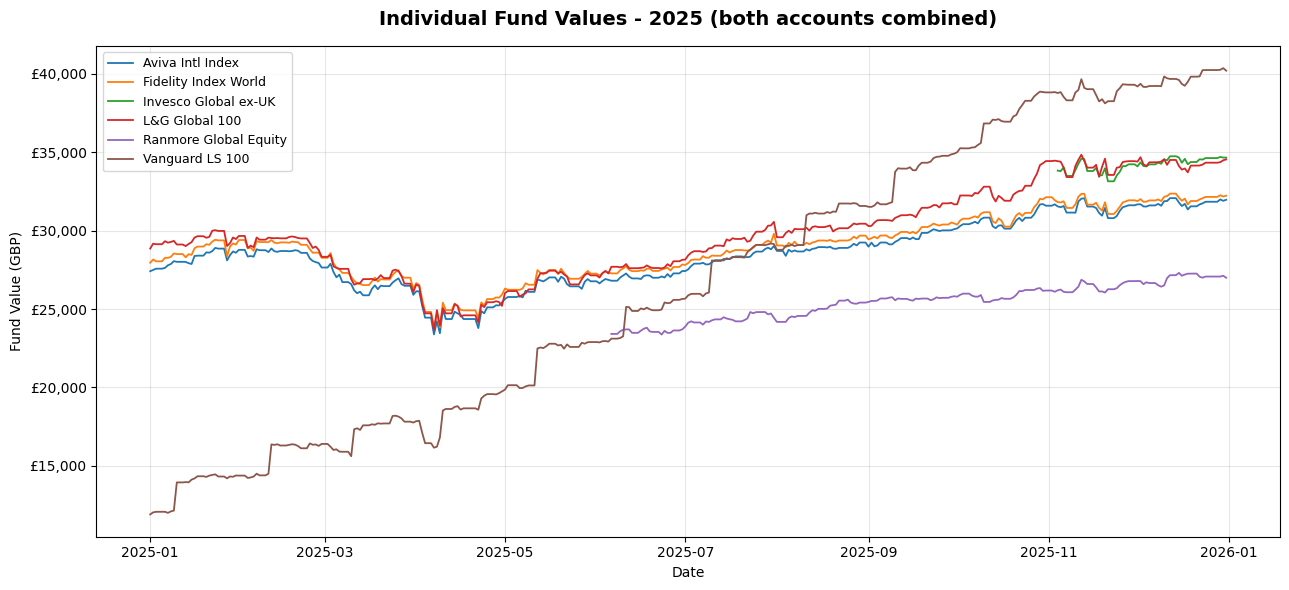

In [13]:
funds_end_2025 = con.execute("""
    SELECT DISTINCT df.fund_id
    FROM fct_daily_holdings fdh
    JOIN dim_fund df   ON df.fund_key  = fdh.fund_key
    JOIN dim_date dd   ON dd.date_key  = fdh.date_key
    WHERE dd.date = (
        SELECT MAX(dd2.date)
        FROM fct_daily_holdings fdh2
        JOIN dim_date dd2 ON dd2.date_key = fdh2.date_key
        WHERE dd2.date <= '2025-12-31'
    )
      AND fdh.holding_type = 'Fund'
      AND fdh.value_gbp > 1
""").fetchdf()['fund_id'].tolist()

fund_values = con.execute(f"""
    SELECT dd.date, df.fund_name, SUM(fdh.value_gbp) AS value_gbp
    FROM fct_daily_holdings fdh
    JOIN dim_fund df   ON df.fund_key  = fdh.fund_key
    JOIN dim_date dd   ON dd.date_key  = fdh.date_key
    WHERE dd.date BETWEEN '2025-01-01' AND '2025-12-31'
      AND fdh.holding_type = 'Fund'
      AND df.fund_id IN ({','.join(f"'{f}'" for f in funds_end_2025)})
    GROUP BY dd.date, df.fund_name
    ORDER BY dd.date
""").fetchdf()

short_names = {
    'Legal & General Global 100 Index Class C - Accumulation': 'L&G Global 100',
    'Fidelity Index World Class P - Accumulation': 'Fidelity Index World',
    'Vanguard LifeStrategy 100% Equity Accumulation': 'Vanguard LS 100',
    'Aviva Investors International Index Tracking Class 2 - Accumulation': 'Aviva Intl Index',
    'Invesco Global ex-UK Enhanced Index Class Z - Accumulation': 'Invesco Global ex-UK',
    'Ranmore Global Equity Investor - Accumulation': 'Ranmore Global Equity',
}
fund_values['label'] = fund_values['fund_name'].map(short_names).fillna(fund_values['fund_name'])

fig, ax = plt.subplots(figsize=(13, 6))
for label, grp in fund_values.groupby('label'):
    ax.plot(grp['date'], grp['value_gbp'], label=label, linewidth=1.3)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Individual Fund Values - 2025 (both accounts combined)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Fund Value (GBP)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Trailing 12-Month Return per Account

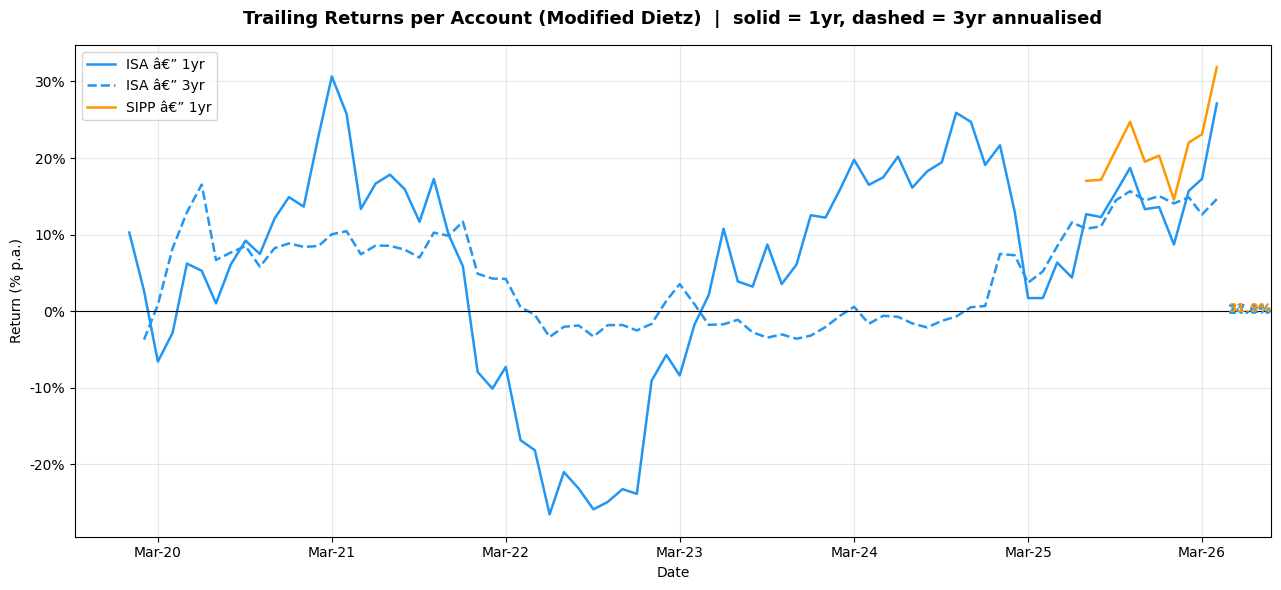

,ISA 1yr,ISA 3yr p.a.,SIPP 1yr,SIPP 3yr p.a.
FY end,,,,
Mar-20,-6.6%,+0.9%,NaN,NaN
Mar-21,+30.7%,+10.1%,NaN,NaN
Mar-22,-7.3%,+4.2%,NaN,NaN
Mar-23,-8.4%,+3.5%,NaN,NaN
Mar-24,+19.8%,+0.6%,NaN,NaN
Mar-25,+1.7%,+3.7%,â€”,â€”
Mar-26,+17.3%,+12.6%,+23.1%,â€”


In [14]:
import matplotlib.dates as mdates
import pandas as pd

returns = con.execute("""
    SELECT year_month, account_id, trailing_12m_return, trailing_36m_return_annualised
    FROM mart_portfolio_returns
    WHERE year_month >= '2020-01'
    ORDER BY year_month, account_id
""").fetchdf()

returns['date'] = pd.to_datetime(returns['year_month'] + '-01')

series_def = {
    ('ISA',  '1yr'): 'trailing_12m_return',
    ('ISA',  '3yr'): 'trailing_36m_return_annualised',
    ('SIPP', '1yr'): 'trailing_12m_return',
    ('SIPP', '3yr'): 'trailing_36m_return_annualised',
}

colours    = {'ISA': '#2196F3', 'SIPP': '#FF9800'}
linestyles = {'1yr': '-', '3yr': '--'}

fig, ax = plt.subplots(figsize=(13, 6))

for (account, window), col in series_def.items():
    s = returns[returns['account_id'] == account].set_index('date')[col].dropna()
    if s.empty:
        continue
    ax.plot(
        s.index, s.values * 100,
        label=f'{account} â€” {window}',
        color=colours[account],
        linestyle=linestyles[window],
        linewidth=1.8,
    )
    ax.annotate(
        f'{s.iloc[-1] * 100:.1f}%',
        xy=(s.index[-1], s.iloc[-1]),
        xytext=(8, 0), textcoords='offset points',
        fontsize=9, fontweight='bold', color=colours[account],
        va='center',
    )

ax.axhline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("Mar-%y"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_title('Trailing Returns per Account (Modified Dietz)  |  solid = 1yr, dashed = 3yr annualised', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Return (% p.a.)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# --- FY-end table (March of each year) ---
fy_end = returns[returns['date'].dt.month == 3].copy()
fy_end['label'] = fy_end['date'].dt.strftime("Mar-%y")

def fmt(v):
    return f"{v * 100:+.1f}%" if pd.notna(v) else 'â€”'

rows = []
for _, row in fy_end.sort_values('date').iterrows():
    rows.append({
        'FY end':  row['label'],
        'Account': row['account_id'],
        '1yr':     fmt(row['trailing_12m_return']),
        '3yr p.a.': fmt(row['trailing_36m_return_annualised']),
    })

table = (
    pd.DataFrame(rows)
    .pivot(index='FY end', columns='Account', values=['1yr', '3yr p.a.'])
    .swaplevel(axis=1)
    .sort_index(axis=1)
)
table.columns = [f'{acct} {metric}' for acct, metric in table.columns]
display(table)

## ISA vs Benchmark Indices

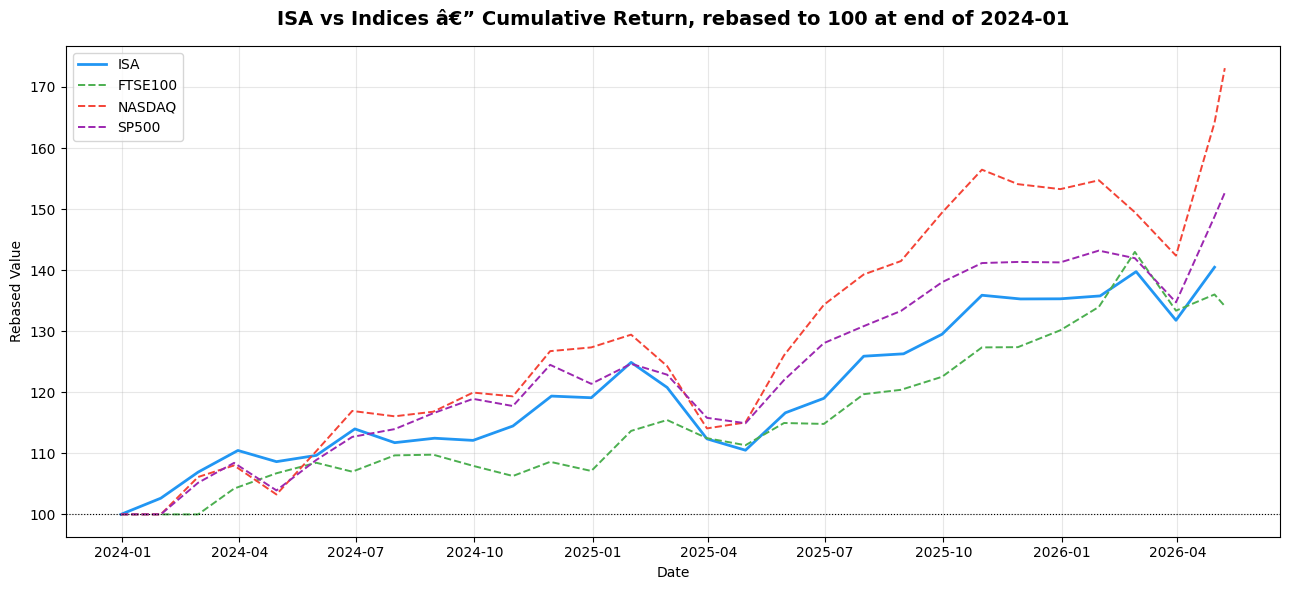

In [ ]:
REBASE_MONTH = '2024-01'

# ISA: chain monthly Modified Dietz returns into a cumulative return index
isa = con.execute(f"""
    SELECT month_end_date, monthly_return
    FROM mart_portfolio_returns
    WHERE account_id = 'ISA'
      AND year_month >= '{REBASE_MONTH}'
    ORDER BY year_month
""").fetchdf()
isa['month_end_date'] = pd.to_datetime(isa['month_end_date'])
isa_cum = (1 + isa.set_index('month_end_date')['monthly_return']).cumprod() * 100

# Benchmarks: rebase month-end levels directly to 100 at the first date in REBASE_MONTH
bench = con.execute(f"""
    SELECT index_id, month_end_date, month_end_level
    FROM mart_benchmarks
    WHERE year_month >= '{REBASE_MONTH}'
    ORDER BY index_id, year_month
""").fetchdf()
bench['month_end_date'] = pd.to_datetime(bench['month_end_date'])
bench['rebased'] = bench.groupby('index_id')['month_end_level'].transform(lambda s: s / s.iloc[0] * 100)

# Common start point
start = pd.Timestamp('2023-12-31')
isa_cum = pd.concat([pd.Series([100.0], index=[start]), isa_cum])

index_styles = {
    'FTSE100': dict(color='#4CAF50', linestyle='--'),
    'SP500':   dict(color='#9C27B0', linestyle='--'),
    'NASDAQ':  dict(color='#F44336', linestyle='--'),
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(isa_cum.index, isa_cum.values, label='ISA', color='#2196F3', linewidth=2.0)
for index_id, grp in bench.groupby('index_id'):
    s = pd.concat([pd.Series([100.0], index=[start]), grp.set_index('month_end_date')['rebased']])
    ax.plot(s.index, s.values, label=index_id, linewidth=1.4, **index_styles.get(index_id, {}))

ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.set_title(f'ISA vs Indices Cumulative Return, rebased to 100 at end of {REBASE_MONTH}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Rebased Value')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Contributions per Account per Month

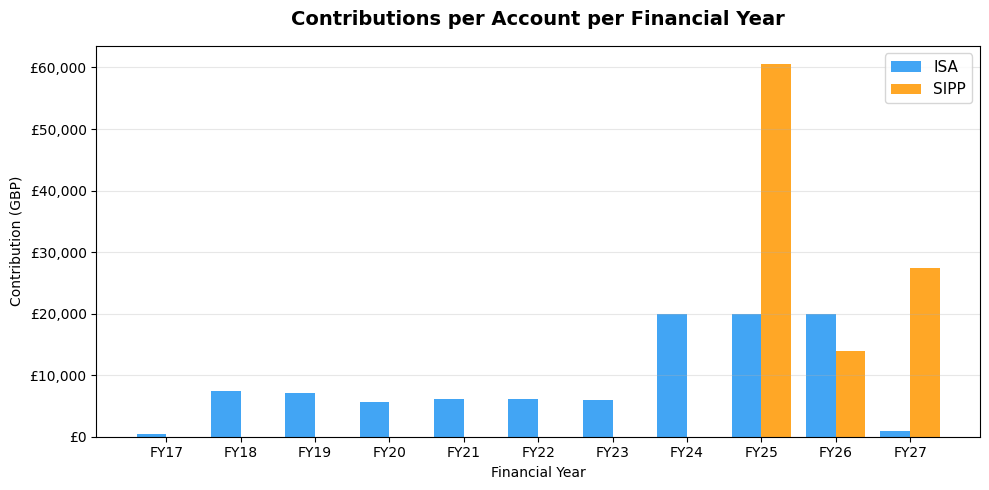

In [16]:
contribs_fy = con.execute("""
    SELECT dd.financial_year, da.account_name AS account_id, SUM(ft.value_gbp) AS contribution_gbp
    FROM fct_transactions ft
    JOIN dim_transaction_type dtt ON dtt.transaction_type_key = ft.transaction_type_key
    JOIN dim_account          da  ON da.account_key           = ft.account_key
    JOIN dim_date             dd  ON dd.date_key              = ft.trade_date_key
    WHERE dtt.contribution_indicator = 'Contribution'
    GROUP BY dd.financial_year, da.account_name
    ORDER BY dd.financial_year, da.account_name
""").fetchdf()

pivot = contribs_fy.pivot(index='financial_year', columns='account_id', values='contribution_gbp').fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(pivot))
width = 0.4
isa_vals  = pivot.get('ISA',  pd.Series(0, index=pivot.index))
sipp_vals = pivot.get('SIPP', pd.Series(0, index=pivot.index))

ax.bar([i - width/2 for i in x], isa_vals,  width=width, label='ISA',  color='#2196F3', alpha=0.85)
ax.bar([i + width/2 for i in x], sipp_vals, width=width, label='SIPP', color='#FF9800', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_title('Contributions per Account per Financial Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Financial Year')
ax.set_ylabel('Contribution (GBP)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

In [17]:
isa_fy25_contribs = con.execute("""
    SELECT
        dd.date                  AS trade_date,
        ft.value_gbp
    FROM fct_transactions ft
    JOIN dim_transaction_type dtt ON dtt.transaction_type_key = ft.transaction_type_key
    JOIN dim_account          da  ON da.account_key           = ft.account_key
    JOIN dim_date             dd  ON dd.date_key              = ft.trade_date_key
    WHERE dtt.contribution_indicator = 'Contribution'
      AND da.account_name = 'ISA'
      AND dd.financial_year = 'FY25'
    ORDER BY dd.date
""").fetchdf()

isa_fy25_contribs['value_gbp'] = isa_fy25_contribs['value_gbp'].map('£{:,.2f}'.format)
isa_fy25_contribs.columns = ['Trade Date', 'Value']
display(isa_fy25_contribs)

,Trade Date,Value
0,2024-04-08,£500.00
1,2024-05-07,£500.00
2,2024-06-07,£500.00
3,2024-07-08,£500.00
4,2024-08-07,£500.00
5,2024-09-09,£500.00
6,2024-10-07,£500.00
7,2024-11-07,£500.00
8,2024-11-11,"£10,000.00"
9,2024-11-12,"£4,000.00"


## Current Holdings

In [18]:
holdings = con.execute("""
    SELECT
        da.account_name AS account_id,
        df.fund_name,
        fdh.units_held,
        fdh.value_gbp
    FROM fct_daily_holdings fdh
    JOIN dim_fund    df ON df.fund_key    = fdh.fund_key
    JOIN dim_account da ON da.account_key = fdh.account_key
    JOIN dim_date    dd ON dd.date_key    = fdh.date_key
    WHERE dd.date = (
        SELECT MAX(dd2.date)
        FROM fct_daily_holdings fdh2
        JOIN dim_date dd2 ON dd2.date_key = fdh2.date_key
    )
      AND fdh.holding_type = 'Fund'
      AND fdh.units_held >= 0.01
    ORDER BY da.account_name, fdh.value_gbp DESC
""").fetchdf()

for account_id, group in holdings.groupby('account_id', sort=True):
    display_df = group[['fund_name', 'units_held', 'value_gbp']].copy()
    display_df.columns = ['Fund', 'Units Held', 'Value (£)']
    display_df['Units Held'] = display_df['Units Held'].map('{:,.1f}'.format)
    display_df['Value (£)']  = display_df['Value (£)'].map('£{:,.0f}'.format)
    display_df = display_df.reset_index(drop=True)

    total = group['value_gbp'].sum()
    print(f'\n{account_id}')
    print(display_df.to_string(index=False))
    print(f"{'Total':<45} {'':>12} £{total:,.0f}")


ISA
                                                               Fund Units Held Value (£)
            Legal & General Global 100 Index Class C - Accumulation    4,063.9   £22,701
                     Vanguard LifeStrategy 100% Equity Accumulation       47.6   £22,461
Aviva Investors International Index Tracking Class 2 - Accumulation    4,797.3   £22,284
         Invesco Global ex-UK Enhanced Index Class Z - Accumulation    3,250.2   £22,232
                        Fidelity Index World Class P - Accumulation    5,030.1   £22,127
                      Ranmore Global Equity Investor - Accumulation       37.2   £21,901
Total                                                      £133,705

SIPP
                                                               Fund Units Held Value (£)
                     Vanguard LifeStrategy 100% Equity Accumulation       48.8   £23,015
            Legal & General Global 100 Index Class C - Accumulation    3,803.6   £21,247
         Invesco Global ex-UK E